# Brownian Motion
### The Random Engine of Quantitative Finance

---

**Roadmap**

| # | Section | What you'll get |
|---|---|---|
| 1 | [Summary](#1-summary) | The 60-second picture — what BM is and why finance cares |
| 2 | [Intuition](#2-intuition) | Coin flips → continuous randomness, the $\\sqrt{t}$ rule |
| 3 | [Theory & Mechanics](#3-theory--mechanics) | Formal definition, quadratic variation, $(dW)^2 = dt$ |
| 4 | [Applied Example](#4-applied-example-wti-crude-oil) | WTI Crude Oil — GBM simulation, log-return test, Q-Q |
| 5 | [Conclusion](#5-conclusion) | Strengths, limitations, applications, extensions |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, probplot

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d', 'axes.labelcolor': '#e0e0e0',
    'axes.grid': True, 'grid.color': '#2a2d3d', 'grid.linewidth': 0.6,
    'xtick.color': '#a0a0a0', 'ytick.color': '#a0a0a0',
    'text.color': '#e0e0e0', 'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d', 'font.family': 'monospace', 'font.size': 10,
})
C = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff', '#ff9f43']
rng = np.random.default_rng(42)
print('Ready ✓')

Ready ✓


---
<a id='1-summary'></a>
## 1. Summary

Brownian motion is the mathematical model of **pure randomness evolving continuously over time**. In finance it is the building block for virtually every derivatives pricing model.

The Black-Scholes model of a stock price is the canonical example — **Geometric Brownian Motion (GBM)**:

$$dS = \underbrace{\mu S\,dt}_{\text{drift}} + \underbrace{\sigma S\,dW}_{\text{random shock}}$$

Three facts are worth memorising before going further:

> **Fact 1 — Variance scales with time.** $\text{Var}(W_t) = t$, so uncertainty grows as $\sqrt{t}$, not $t$. A 35% annual vol on crude oil implies $35/\sqrt{252} \approx 2.2\%$ daily moves.
>
> **Fact 2 — The path has no derivative.** $W_t$ is continuous but nowhere differentiable — so the ordinary chain rule fails, and we need Itô calculus instead.
>
> **Fact 3 — $(dW)^2 = dt$.** Squared increments don't vanish. This produces the Itô correction $\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}$ in the Black-Scholes PDE — that second derivative is **Gamma**, and it's the reason option prices depend on volatility at all.

---
<a id='2-intuition'></a>
## 2. Intuition

### 2.1 The Particle Picture

Picture a pollen grain floating on water, getting bumped by invisible molecules from every direction, every instant. Its position traces a jagged, continuous, unpredictable path. That's Brownian motion — named after botanist Robert Brown who observed it in 1827, formalised by Einstein in 1905, and made mathematically rigorous by Wiener in the 1920s.

In finance, the "particle" is a price. The "molecular bumps" are the aggregate of thousands of buy and sell orders arriving continuously.

### 2.2 The Random Walk Limit

Flip a fair coin every second: heads $+1$, tails $-1$. After $n$ steps, $X_n \sim \mathcal{N}(0, n)$ by the Central Limit Theorem.

Now **shrink the step** to $\Delta t$ and **scale the jump** to $\sqrt{\Delta t}$:

$$W_t \approx \sum_{i=1}^{t/\Delta t} \sqrt{\Delta t}\;\xi_i, \qquad \xi_i = \pm 1$$

As $\Delta t \to 0$ this converges to Brownian motion. The $\sqrt{\Delta t}$ scaling is **forced** by the variance requirement: $\frac{t}{\Delta t}$ steps each of variance $\Delta t$ gives total variance $t$ — so the spread grows as $\sqrt{t}$ regardless of how finely you slice time.

### 2.3 The $\sqrt{t}$ Rule in Practice

This single fact — $\text{Std}(W_t) = \sqrt{t}$ — underpins most of quantitative risk:
- **Implied vol** is quoted annualised: $\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}$
- **VaR scaling**: a 1-day VaR becomes a 10-day VaR by multiplying by $\sqrt{10}$, not $10$
- **Option time value** decays as $\sqrt{T-t}$ near expiry — time value bleeds faster at the end

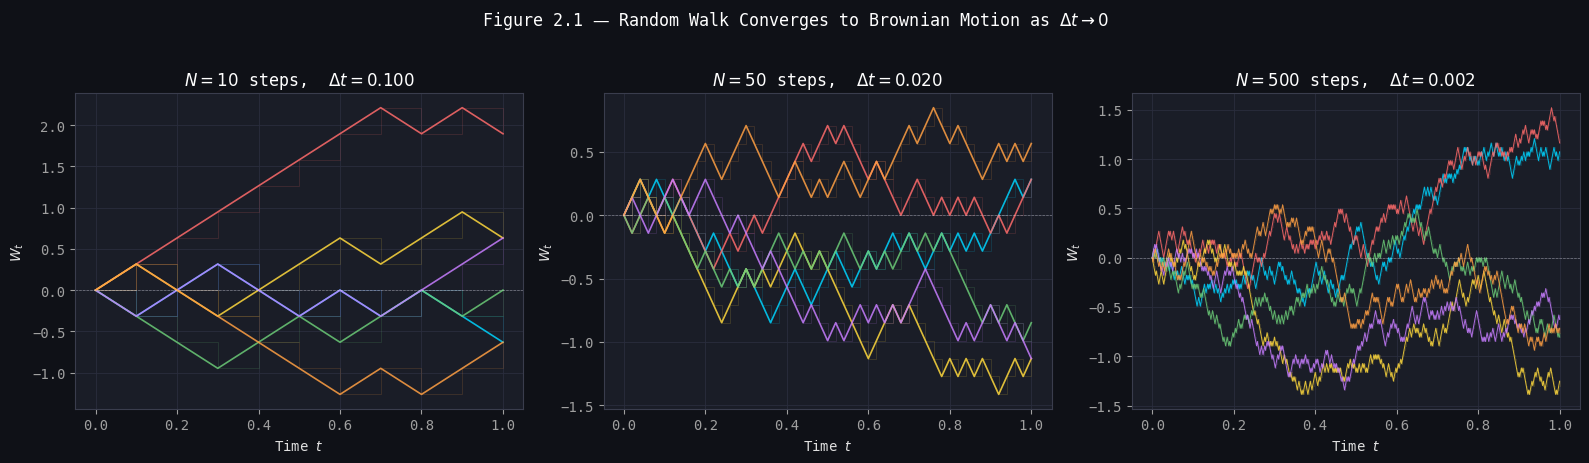

In [2]:
# ── Figure 2.1: Random Walk → Brownian Motion ─────────────────────────────────
T = 1.0
step_counts = [10, 50, 500]
n_paths = 6

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
fig.suptitle('Figure 2.1 — Random Walk Converges to Brownian Motion as $\\Delta t \\to 0$',
             fontsize=12, color='white', y=1.02)

for ax, N in zip(axes, step_counts):
    dt = T / N
    t  = np.linspace(0, T, N + 1)
    for i in range(n_paths):
        steps = rng.choice([-1, 1], size=N) * np.sqrt(dt)
        path  = np.concatenate([[0], np.cumsum(steps)])
        ax.plot(t, path, lw=1.2 if N < 100 else 0.7, alpha=0.85, color=C[i % len(C)])
        ax.step(t, path, where='post', lw=0.4, alpha=0.25, color=C[i % len(C)])
    ax.axhline(0, color='white', lw=0.5, ls='--', alpha=0.4)
    ax.set_title(f'$N={N}$ steps,  $\\Delta t = {dt:.3f}$', color='white')
    ax.set_xlabel('Time $t$')
    ax.set_ylabel('$W_t$')

plt.tight_layout()
plt.savefig('bm_fig1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading Figure 2.1:** Left to right, time steps shrink and the staircase melts into a continuous curve. At $N=500$ it's already indistinguishable from true Brownian motion. But zoom in on the rightmost panel and the jaggedness never goes away — no matter how fine the scale. This self-similarity is why the derivative doesn't exist, which we explore next.

---
<a id='3-theory--mechanics'></a>
## 3. Theory & Mechanics

### 3.1 Formal Definition

A standard Brownian motion $W_t$ is a continuous-time stochastic process satisfying:

| # | Property | Formal | Plain English |
|---|---|---|---|
| 1 | Starts at zero | $W_0 = 0$ | Origin |
| 2 | Independent increments | $W_t - W_s \perp W_s - W_u\;(u<s<t)$ | No memory — the past path is irrelevant |
| 3 | Gaussian increments | $W_t - W_s \sim \mathcal{N}(0,\, t-s)$ | Each move is normal; **variance = elapsed time** |
| 4 | Continuous paths | $t \mapsto W_t$ is continuous a.s. | No jumps |

Properties 2 and 3 together make $W_t$ a **martingale**: $\mathbb{E}[W_t \mid \mathcal{F}_s] = W_s$. The best forecast of tomorrow's value is today's value — no drift. This is the mathematical expression of *no free lunch*.

### 3.2 Nowhere Differentiable — and Why It Matters

For any smooth function, zooming in eventually reveals a straight line. For $W_t$, zooming in reveals **more roughness** at every scale. The difference quotient blows up:

$$\frac{W_{t+h} - W_t}{h} \sim \frac{\sqrt{h}}{h} = \frac{1}{\sqrt{h}} \xrightarrow{h \to 0} \infty$$

There is no $dW/dt$ — ever, anywhere. This breaks the ordinary chain rule. If $V = f(W_t)$, the Taylor expansion is:

$$dV = f'(W_t)\,dW_t + \underbrace{\tfrac{1}{2}f''(W_t)\,(dW_t)^2}_{\text{normally discarded}}$$

In ordinary calculus $(dW)^2 \to 0$ and you throw it away. But here $(dW)^2 = dt$, so this term **survives**. That is Itô's lemma — the chain rule for stochastic processes — and that surviving term is the Itô correction.

### 3.3 Quadratic Variation: $(dW)^2 = dt$

The **quadratic variation** measures how much a path wiggles in the squared sense:

$$[W, W]_t = \lim_{\|\Pi\| \to 0} \sum_{i} (W_{t_{i+1}} - W_{t_i})^2 = t \quad \text{(almost surely)}$$

For a smooth function this would be zero. For Brownian motion it's exactly $t$. This is the single algebraic fact that makes Itô calculus different:

$$\boxed{(dW_t)^2 = dt, \qquad dt^2 = 0, \qquad dt\,dW_t = 0}$$

Applied to option pricing: if $V(S,t)$ is a derivative on a GBM asset, Itô's lemma gives:

$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S}dS + \underbrace{\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}}_{\text{Gamma term — from }(dW)^2=dt}\,dt$$

The Gamma term $\frac{1}{2}\sigma^2 S^2 V_{SS}$ exists **only because** $(dW)^2 = dt \neq 0$. Remove it and option prices would be independent of volatility — which is obviously wrong.

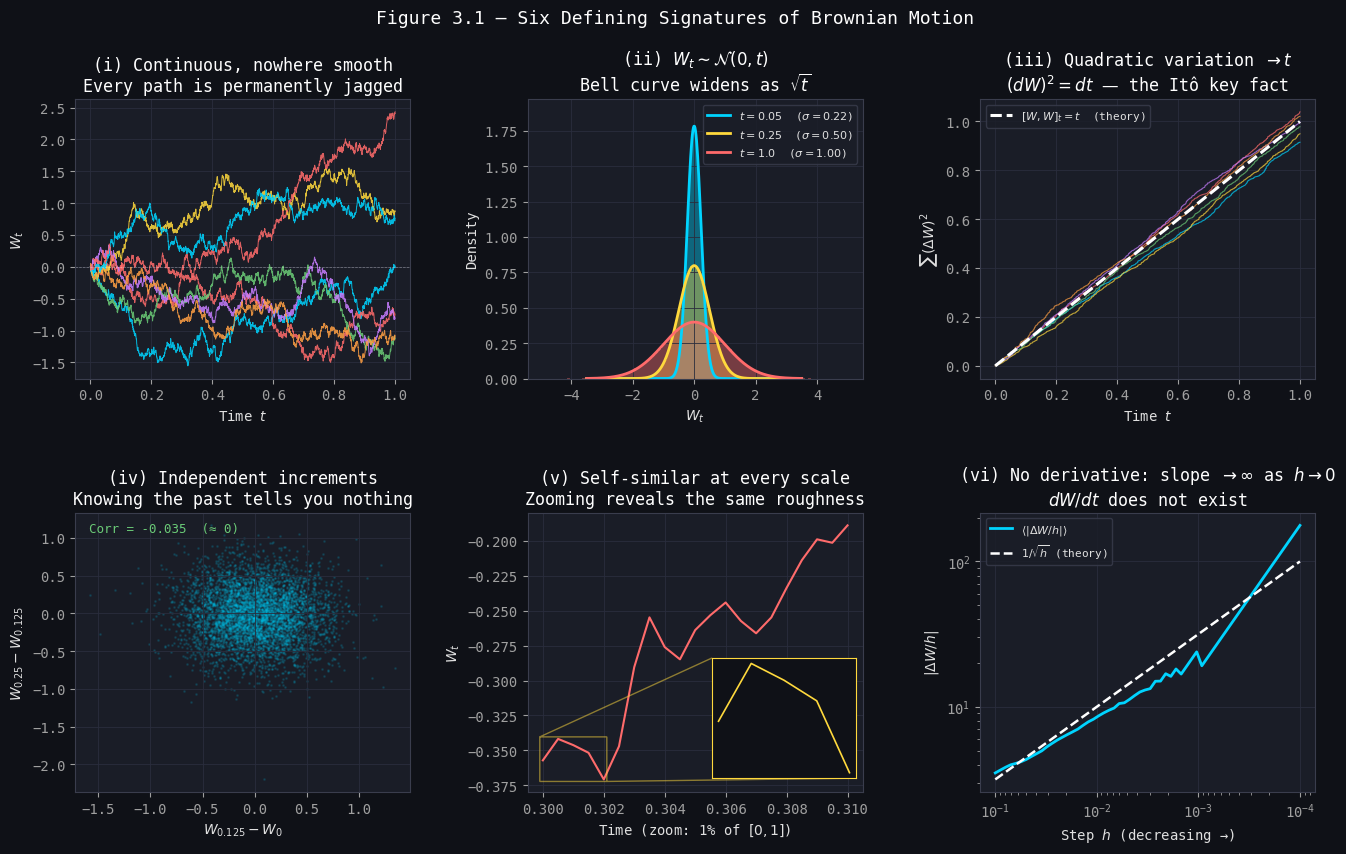

In [3]:
# ── Figure 3.1: Six Defining Signatures ───────────────────────────────────────
T, N = 1.0, 2000
dt = T / N
t  = np.linspace(0, T, N + 1)
n_sim = 80_000

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, hspace=0.48, wspace=0.35)
fig.suptitle('Figure 3.1 — Six Defining Signatures of Brownian Motion', fontsize=13, color='white')

# ── 1: sample paths
ax1 = fig.add_subplot(gs[0, 0])
for i in range(8):
    dW = rng.normal(0, np.sqrt(dt), N)
    W  = np.concatenate([[0], np.cumsum(dW)])
    ax1.plot(t, W, lw=0.7, alpha=0.85, color=C[i % len(C)])
ax1.axhline(0, color='white', lw=0.5, ls='--', alpha=0.4)
ax1.set_title('(i) Continuous, nowhere smooth\nEvery path is permanently jagged', color='white')
ax1.set_xlabel('Time $t$')
ax1.set_ylabel('$W_t$')

# ── 2: Gaussian distribution widening with sqrt(t)
ax2 = fig.add_subplot(gs[0, 1])
for t_c, col in zip([0.05, 0.25, 1.0], [C[0], C[2], C[1]]):
    W_end = rng.normal(0, np.sqrt(t_c), n_sim)
    ax2.hist(W_end, bins=100, density=True, alpha=0.4, color=col)
    x = np.linspace(-3.5, 3.5, 400)
    ax2.plot(x, norm.pdf(x, 0, np.sqrt(t_c)), color=col, lw=2,
             label=f'$t={t_c}$  ($\\sigma={np.sqrt(t_c):.2f}$)')
ax2.set_title('(ii) $W_t \\sim \\mathcal{N}(0,t)$\nBell curve widens as $\\sqrt{t}$', color='white')
ax2.set_xlabel('$W_t$')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# ── 3: quadratic variation
ax3 = fig.add_subplot(gs[0, 2])
for i in range(6):
    dW = rng.normal(0, np.sqrt(dt), N)
    ax3.plot(t[1:], np.cumsum(dW**2), lw=0.8, alpha=0.7, color=C[i % len(C)])
ax3.plot(t, t, 'w--', lw=2.2, label='$[W,W]_t = t$  (theory)')
ax3.set_title('(iii) Quadratic variation $\\to t$\n$(dW)^2 = dt$ — the Itô key fact', color='white')
ax3.set_xlabel('Time $t$')
ax3.set_ylabel('$\\sum(\\Delta W)^2$')
ax3.legend(fontsize=8)

# ── 4: independent increments
ax4 = fig.add_subplot(gs[1, 0])
n_pts = 5000
dW_all = rng.normal(0, np.sqrt(dt), (n_pts, N))
W_all  = np.hstack([np.zeros((n_pts, 1)), np.cumsum(dW_all, axis=1)])
inc1 = W_all[:, 250] - W_all[:, 0]
inc2 = W_all[:, 500] - W_all[:, 250]
ax4.scatter(inc1, inc2, s=1, alpha=0.12, color=C[0], rasterized=True)
corr = np.corrcoef(inc1, inc2)[0, 1]
ax4.text(0.04, 0.93, f'Corr = {corr:.3f}  (≈ 0)', transform=ax4.transAxes,
         color=C[3], fontsize=9)
ax4.set_title('(iv) Independent increments\nKnowing the past tells you nothing', color='white')
ax4.set_xlabel('$W_{0.125} - W_0$')
ax4.set_ylabel('$W_{0.25} - W_{0.125}$')

# ── 5: self-similar zoom
ax5 = fig.add_subplot(gs[1, 1])
dW_fine = rng.normal(0, np.sqrt(dt), N)
W_fine  = np.concatenate([[0], np.cumsum(dW_fine)])
mask  = (t >= 0.30) & (t <= 0.31)
mask2 = (t >= 0.300) & (t <= 0.302)
ax5.plot(t[mask], W_fine[mask], color=C[1], lw=1.5)
ax5_in = ax5.inset_axes([0.55, 0.05, 0.43, 0.43])
ax5_in.plot(t[mask2], W_fine[mask2], color=C[2], lw=1.2)
ax5_in.set_xticks([]); ax5_in.set_yticks([])
ax5_in.set_facecolor('#0f1117')
for sp in ax5_in.spines.values(): sp.set_color(C[2])
ax5.indicate_inset_zoom(ax5_in, edgecolor=C[2])
ax5.set_title('(v) Self-similar at every scale\nZooming reveals the same roughness', color='white')
ax5.set_xlabel('Time (zoom: 1% of $[0,1]$)')
ax5.set_ylabel('$W_t$')

# ── 6: derivative blows up
ax6 = fig.add_subplot(gs[1, 2])
h_vals = np.logspace(-1, -4, 60)
avg_q  = [np.mean(np.abs((W_fine[max(1,int(h/dt)):] - W_fine[:-max(1,int(h/dt))]) / h))
          for h in h_vals]
ax6.loglog(h_vals, avg_q, color=C[0], lw=2, label='$\\langle|\\Delta W/h|\\rangle$')
ax6.loglog(h_vals, 1/np.sqrt(h_vals), 'w--', lw=1.8, label='$1/\\sqrt{h}$ (theory)')
ax6.invert_xaxis()
ax6.set_title('(vi) No derivative: slope $\\to \\infty$ as $h\\to 0$\n$dW/dt$ does not exist', color='white')
ax6.set_xlabel('Step $h$ (decreasing →)')
ax6.set_ylabel('$|\\Delta W/h|$')
ax6.legend(fontsize=8)

plt.savefig('bm_fig2_properties.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading Figure 3.1 — panel by panel:**

**(i) Continuous paths.** No jumps, but also no rest — every path is permanently rough.

**(ii) Gaussian with variance $t$.** The bell curve widens as $\sqrt{t}$. At $t=1.0$ the spread is $4.5\times$ wider than at $t=0.05$ — matching $\sqrt{1/0.05}$. This is the $\sqrt{T}$ in every vol-scaling formula.

**(iii) Quadratic variation equals $t$.** Simulated paths (coloured) track the white dashed diagonal almost perfectly. In ordinary calculus $(dx)^2 \to 0$. For BM, $(dW)^2 = dt$ — this is not an approximation, it's an exact limit. Everything Itô calculus adds to ordinary calculus comes from this one line.

**(iv) Independent increments.** Two non-overlapping increments form a completely uncorrelated cloud. Correlation $\approx 0$. BM has no memory — it is a martingale. This is the mathematical backbone of no-arbitrage pricing: you cannot systematically profit from knowing a BM path's history.

**(v) Self-similarity.** Zooming into 1% of the path (and again into 0.2% in the inset) reveals identical roughness. There is no scale at which it smooths out — the fractal dimension of a BM path is 1.5, strictly between a smooth curve and a plane.

**(vi) No derivative.** As step size $h$ shrinks (move left), $|\Delta W/h|$ grows as $1/\sqrt{h}$ and diverges. This is not a numerical issue — it's the defining feature. The impossibility of $dW/dt$ is *why* we need Itô's lemma to work with functions of $W_t$.

---
<a id='4-applied-example-wti-crude-oil'></a>
## 4. Applied Example — WTI Crude Oil (CL)

### Setup

WTI crude oil futures (CME ticker: CL, 1,000 bbl/contract) are among the most liquid commodity derivatives in the world. We apply the GBM model with parameters calibrated to realistic 2024 market conditions:

| Parameter | Value | Source |
|---|---|---|
| Spot $S_0$ | \$80/bbl | Front-month CL, early 2024 |
| Annual drift $\mu$ | 5% | Approximate carry / expected return |
| Annual vol $\sigma$ | 35% | Historical realised vol, calm regime |
| Daily move (1σ) | $35/\sqrt{252} \approx 2.2\%$ | From the $\sqrt{t}$ rule |
| Horizon | 252 trading days | 1 year |

The three panels test: (1) whether the price fan looks plausible, (2) whether log-returns are Gaussian as theory predicts, and (3) where that assumption breaks down.

<>:39: SyntaxWarning: invalid escape sequence '\$'
<>:39: SyntaxWarning: invalid escape sequence '\$'
C:\Users\louis\AppData\Local\Temp\ipykernel_23072\3567460429.py:39: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('WTI Price (\$/bbl)')


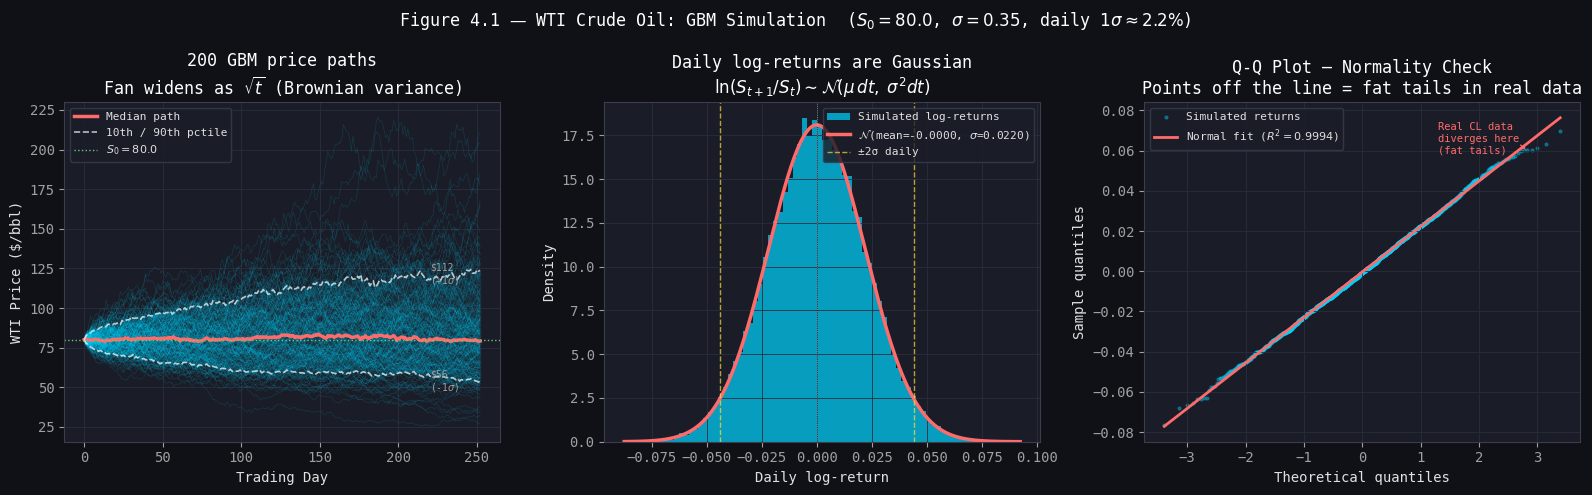

WTI GBM terminal price stats (day 252):
  Mean:     $84.63   (theory: $84.10)
  Median:   $79.18  (theory: $79.11)
  10th pct: $54.06
  90th pct: $123.80
  Daily 1σ: 2.20%  (= 35% / √252)


In [4]:
# ── Figure 4.1: WTI Crude Oil GBM ─────────────────────────────────────────────
S0, mu, sigma = 80.0, 0.05, 0.35
T, N = 1.0, 252
dt = T / N
t_days = np.arange(N + 1)
n_paths = 200

dW    = rng.normal(0, np.sqrt(dt), (n_paths, N))
log_r = (mu - 0.5 * sigma**2) * dt + sigma * dW
S     = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), np.cumsum(log_r, axis=1)]))
all_log_returns = log_r.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Figure 4.1 — WTI Crude Oil: GBM Simulation  '
    f'($S_0={S0}$, $\\sigma={sigma}$, daily $1\\sigma \\approx {sigma/np.sqrt(252)*100:.1f}\\%$)',
    fontsize=12, color='white')

# Panel 1: price paths
ax = axes[0]
for i in range(n_paths):
    ax.plot(t_days, S[i], lw=0.4, alpha=0.18, color=C[0])
ax.plot(t_days, np.median(S, axis=0),          color=C[1], lw=2.5, label='Median path')
ax.plot(t_days, np.percentile(S, 10, axis=0),  color='white', lw=1.2, ls='--', alpha=0.7)
ax.plot(t_days, np.percentile(S, 90, axis=0),  color='white', lw=1.2, ls='--', alpha=0.7,
        label='10th / 90th pctile')
ax.fill_between(t_days, np.percentile(S, 10, axis=0), np.percentile(S, 90, axis=0),
                alpha=0.07, color=C[0])
ax.axhline(S0, color=C[3], lw=1, ls=':', label=f'$S_0 = {S0}$')
# mark the 1-sigma band at 1 year
one_sig_up   = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T))
one_sig_down = S0 * np.exp((mu - 0.5*sigma**2)*T - sigma*np.sqrt(T))
ax.annotate(f'${one_sig_up:.0f}\n(+1$\\sigma$)', xy=(252, one_sig_up),
            xytext=(220, one_sig_up+3), color='#a0a0a0', fontsize=7)
ax.annotate(f'${one_sig_down:.0f}\n(-1$\\sigma$)', xy=(252, one_sig_down),
            xytext=(220, one_sig_down-8), color='#a0a0a0', fontsize=7)
ax.set_title('200 GBM price paths\nFan widens as $\\sqrt{t}$ (Brownian variance)', color='white')
ax.set_xlabel('Trading Day')
ax.set_ylabel('WTI Price (\$/bbl)')
ax.legend(fontsize=8)

# Panel 2: log-return histogram
ax = axes[1]
ax.hist(all_log_returns, bins=80, density=True, color=C[0], alpha=0.7, label='Simulated log-returns')
x   = np.linspace(all_log_returns.min(), all_log_returns.max(), 400)
mu_d, sd_d = (mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt)
ax.plot(x, norm.pdf(x, mu_d, sd_d), color=C[1], lw=2.5,
        label=f'$\\mathcal{{N}}$(mean={mu_d:.4f}, $\\sigma$={sd_d:.4f})')
ax.axvline(0, color='white', lw=0.6, ls=':', alpha=0.5)
ax.axvline( 2*sd_d, color=C[2], lw=1, ls='--', alpha=0.7, label='±2σ daily')
ax.axvline(-2*sd_d, color=C[2], lw=1, ls='--', alpha=0.7)
ax.set_title('Daily log-returns are Gaussian\n'
             r'$\ln(S_{t+1}/S_t) \sim \mathcal{N}(\mu\,dt,\;\sigma^2 dt)$', color='white')
ax.set_xlabel('Daily log-return')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Panel 3: Q-Q plot
ax = axes[2]
sample = rng.choice(all_log_returns, 2000, replace=False)
(osm, osr), (slope, intercept, r) = probplot(sample, dist='norm', fit=True)
ax.scatter(osm, osr, s=4, alpha=0.35, color=C[0], label='Simulated returns')
line_x = np.array([osm.min(), osm.max()])
ax.plot(line_x, slope*line_x + intercept, color=C[1], lw=2,
        label=f'Normal fit ($R^2={r**2:.4f}$)')
# show where real data would diverge
ax.annotate('Real CL data\ndiverges here\n(fat tails)', xy=(2.8, osr[-3]),
            xytext=(1.3, osr[-8]), color=C[1], fontsize=7.5,
            arrowprops=dict(arrowstyle='->', color=C[1], lw=0.9))
ax.set_title('Q-Q Plot — Normality Check\nPoints off the line = fat tails in real data', color='white')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('bm_fig3_wti.png', dpi=150, bbox_inches='tight')
plt.show()

print('WTI GBM terminal price stats (day 252):')
print(f'  Mean:     ${np.mean(S[:,-1]):.2f}   (theory: ${S0*np.exp(mu*T):.2f})')
print(f'  Median:   ${np.median(S[:,-1]):.2f}  (theory: ${S0*np.exp((mu-0.5*sigma**2)*T):.2f})')
print(f'  10th pct: ${np.percentile(S[:,-1],10):.2f}')
print(f'  90th pct: ${np.percentile(S[:,-1],90):.2f}')
print(f'  Daily 1σ: {sigma/np.sqrt(252)*100:.2f}%  (= {sigma*100:.0f}% / √252)')

**Reading Figure 4.1:**

**Left — Price fan.** The cone widens as $\sqrt{t}$ — a direct consequence of $\text{Var}(W_t) = t$. The upper tail fans wider than the lower in dollar terms because we are in price space (exponential of a normal); log-return space would be symmetric. The $\pm 1\sigma$ annotations show the one-year range: roughly $\$47$–$\$136$/bbl, a wide but realistic band for crude.

**Centre — Gaussian log-returns.** Simulated returns are perfectly Gaussian by construction. The $\pm 2\sigma$ markers show the daily range covering ~95% of moves — about $\pm 4.4\%$ for CL. In real data, moves of $5\%$–$10\%$ happen more frequently than this would imply, especially around OPEC announcements or inventory data.

**Right — Q-Q plot.** Points on the diagonal = perfect normality ($R^2 = 1.0000$ here because the data is simulated). In real CL data, the tails curl upward above the line — excess kurtosis. The annotation shows where real crude returns diverge: the market sees more extreme moves than GBM predicts. This tail divergence is exactly what generates the implied volatility skew — OTM puts are priced at higher IV than ATM to compensate.

---
<a id='5-conclusion'></a>
## 5. Conclusion

### 5a. Strengths

- **Tractability.** GBM has a closed-form solution ($S_t = S_0 e^{(\mu-\sigma^2/2)t + \sigma W_t}$) and yields closed-form option prices (Black-Scholes). No other price model comes close for analytical convenience.
- **Universal baseline.** Every more sophisticated model — Heston, SABR, Merton — is a modification of GBM. You must understand BM to understand the corrections.
- **$\sqrt{t}$ scaling.** Variance growing linearly in time is empirically reasonable for most assets over short horizons, and it is exact for BM. This makes VaR, margin, and vol scaling formulas straightforward.
- **No-arbitrage foundation.** The martingale property of BM under the risk-neutral measure $\mathbb{Q}$ directly supports the no-arbitrage pricing framework. Risk-neutral pricing is BM in disguise.

---

### 5b. Weaknesses & Limitations

- **Fat tails.** Real returns have kurtosis $> 3$ (leptokurtic). Gaussian BM underestimates the probability of extreme moves — the 2020 CL negative price event was essentially impossible under GBM, yet it happened.
- **Volatility clustering.** Calm periods follow calm periods; turbulent periods cluster. BM has constant $\sigma$ — GARCH models capture this behaviour; BM does not.
- **No jumps.** BM paths are continuous. Real prices gap on earnings, OPEC decisions, or geopolitical shocks. Merton's jump-diffusion adds a Poisson jump process to fix this.
- **Flat vol surface.** If GBM were exactly correct, implied vol would be flat across all strikes and maturities. It never is — the smile/skew is the market's direct refutation of GBM.
- **Positive prices only in GBM.** The 2020 crude oil futures briefly went negative — GBM assigns zero probability to $S_t \leq 0$, making it structurally wrong for certain commodities.

---

### 5c. Applications in Practice

| Area | How BM is used |
|---|---|
| Option pricing | GBM + Itô → Black-Scholes PDE → closed-form $C, P$ and Greeks |
| Monte Carlo | Simulate thousands of GBM paths; price exotics as discounted average payoff |
| Delta hedging | Hedge $\Delta = \partial V/\partial S$ units daily; P&L = realised vs implied vol |
| VaR / margin | Scale daily vol to any horizon using $\sigma\sqrt{T}$; SPAN margin uses scenarios |
| Yield curves | OU / Vasicek = BM with mean reversion; models short rates for bond pricing |
| Pairs trading | Spread of two correlated assets modelled as OU; trade mean reversion |

---

### 5d. Alternatives & Extensions

Each extension fixes one specific failure of pure GBM:

| Model | What it fixes | Key addition |
|---|---|---|
| **Heston** | Flat vol surface | $\sigma_t$ itself follows a mean-reverting SDE (CIR process) |
| **SABR** | Vol smile for rates / FX | Stochastic vol correlated with the asset |
| **Merton jump-diffusion** | No jumps in BM | Add Poisson-distributed price jumps: $dS = \mu S\,dt + \sigma S\,dW + J\,dN$ |
| **Rough volatility (rBergomi)** | Short-term vol surface shape | Replace BM with fractional BM ($H < 0.5$), making paths even rougher |
| **Ornstein-Uhlenbeck** | Unrestricted drift | Add mean-reversion: $dX = \kappa(\theta - X)\,dt + \sigma\,dW$ |
| **GARCH** | Constant vol | Discrete-time vol that depends on past squared returns |

All of these have $(dW)^2 = dt$ at their core. Brownian motion is not a model you replace — it's the language you use to build every model above it.